In [1]:
import pandas as pd
from training_logs_analysis import parse_client_csv


In [2]:
path = "/home/brian_bosho/FP/FP/federated-gnn/src/results/yaml_test_results_5clients/Cora_adjacency_GCN/training_Cora_adjacency_GCN_20250503_211641.csv"

In [3]:
dfs = parse_client_csv(path)

In [4]:
dfs.keys()


dict_keys(['loss_df', 'acc_df', 'loss_df_step', 'acc_df_step', 'avg_loss_df', 'avg_acc_df', 'epoch_loss_df', 'epoch_acc_df', 'final_loss_df', 'final_acc_df'])

In [5]:
final_loss_df = dfs['final_loss_df']
final_loss_df


client_id,0,1,2,3,4
round,,,,,
0,1.511729,1.714927,1.316724,1.608046,1.553374
1,1.352808,1.380581,1.075114,1.522972,1.327772
2,1.155474,1.090317,0.905097,1.379927,1.254807
3,0.986516,1.092607,0.762016,1.224443,1.042193
4,0.971870,0.914589,0.600787,1.175818,0.988997
5,0.765988,0.721967,0.586181,1.051511,0.901258
6,0.914893,0.707734,0.423998,0.956108,0.816093
7,0.663801,0.594324,0.370145,0.873491,0.706497
8,0.742756,0.664011,0.435593,0.722421,0.731878


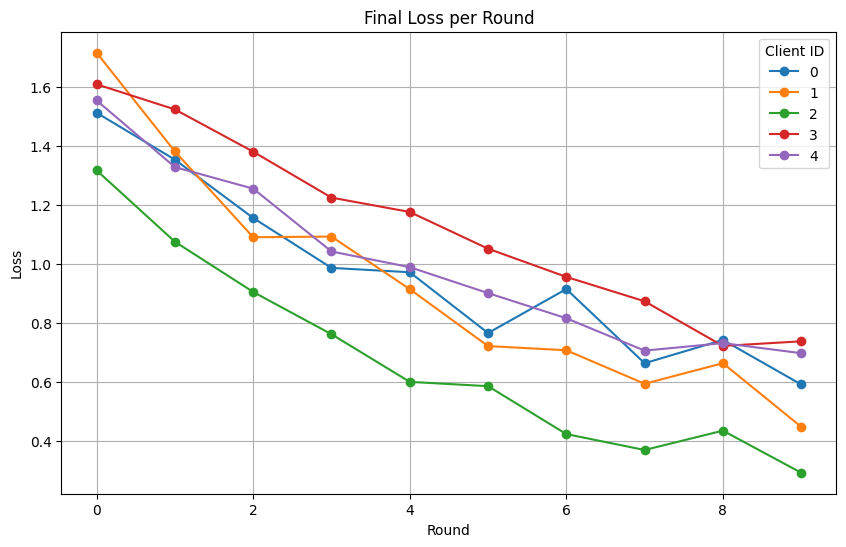

In [6]:
# plot final loss
import matplotlib.pyplot as plt
final_loss_df.plot(figsize=(10, 6), marker='o')
plt.title("Final Loss per Round")
plt.xlabel("Round")
plt.ylabel("Loss")
plt.grid(True)
plt.legend(title="Client ID")

### lets review the results folder results

In [1]:
from process_results import process_results_folder_json

In [2]:
test_results = "/home/brian_bosho/FP/FP/federated-gnn/src/results/yaml_test_results_5clients"

In [3]:
df = process_results_folder_json(test_results)
df

INFO: Scanning folder: /home/brian_bosho/FP/FP/federated-gnn/src/results/yaml_test_results_5clients
INFO: Reading: /home/brian_bosho/FP/FP/federated-gnn/src/results/yaml_test_results_5clients/Cora_adjacency_GCN/results_Cora_adjacency_GCN_20250503_211641.json
INFO: Reading: /home/brian_bosho/FP/FP/federated-gnn/src/results/yaml_test_results_5clients/Cora_full_GCN/results_Cora_full_GCN_20250503_211618.json
INFO: Successfully created DataFrame with 2 rows.


,device,data_loading_option,model_type,dataset,num_clients,beta,hop,fulltraining_flag,global_results,client_results,average_global_result,average_client_result,std_global,std_client,experiment_id
0,cuda,adjacency,GCN,Cora,5,1,1,False,[0.656],[0.6805602731152979],0.656,0.680560,0.0,0.0,results_Cora_adjacency_GCN_20250503_211641
1,cuda,full,GCN,Cora,5,1,1,False,[0.7],[0.7063045451617194],0.700,0.706305,0.0,0.0,results_Cora_full_GCN_20250503_211618


In [7]:
def compute_summary_statistics(json_file):
    """
    Compute summary statistics for an experiment and update its JSON file.
    """
    import json
    
    with open(json_file, 'r') as f:
        data = json.load(f)
    
    clients = data.get("clients", [])
    if not clients:
        return
    
    # Compute summary statistics
    summary = {
        "avg_iterations": sum(c["iterations"] for c in clients) / len(clients),
        "avg_runtime": sum(c["runtime"] for c in clients) / len(clients),
        "convergence_rate": sum(1 for c in clients if c["converged"]) / len(clients),
        "initial_zeros": sum(c["initial_zeros"] for c in clients),
        "final_zeros": sum(c["final_zeros"] for c in clients),
    }
    
    # Calculate zero reduction percentage
    if summary["initial_zeros"] > 0:
        summary["zero_reduction_percent"] = 100 * (1 - summary["final_zeros"] / summary["initial_zeros"])
    else:
        summary["zero_reduction_percent"] = 0
    
    # Add summary to the experiment data
    data["summary"] = summary
    
    # Write back the updated experiment data
    with open(json_file, 'w') as f:
        json.dump(data, f, indent=2)

    return summary

In [8]:
json_file  = "/home/brian_bosho/FP/FP/federated-gnn/logs/propagation_stats/prop_exp_20250504-013806_adjacency.json"

In [9]:
stats = compute_summary_statistics(json_file)
stats

{'avg_iterations': 50.0,
 'avg_runtime': 0.06848459243774414,
 'convergence_rate': 0.0,
 'initial_zeros': 5429,
 'final_zeros': 0,
 'zero_reduction_percent': 100.0}

In [12]:
import json
import pandas as pd

def process_fp_json_file(filepath):
    # Load JSON from file
    with open(filepath, 'r') as f:
        data = json.load(f)
    
    clients = data.get("clients", [])
    
    summary_data = []
    deltas_data = {}
    energies_data = {}

    for client in clients:
        client_id = client["client_id"]
        deltas = client.get("deltas", [])
        deltas_data[client_id] = deltas
        energies = client.get("energies", [])
        energies_data[client_id] = energies

        # Exclude deltas from the summary
        summary_entry = {k: v for k, v in client.items() if k != "deltas"}
        summary_data.append(summary_entry)
    
    # Create the summary DataFrame
    fp_stats_df = pd.DataFrame(summary_data)

    # Create the deltas DataFrame
    deltas_df = pd.DataFrame.from_dict(deltas_data, orient='columns')
    deltas_df.index.name = 'iteration'

    # Create the energies DataFrame
    energies_df = pd.DataFrame.from_dict(energies_data, orient='columns')
    energies_df.index.name = 'iteration'

    return fp_stats_df, deltas_df, energies_df

# Example usage:
# fp_stats_df, deltas_df = process_fp_json_file("your_json_file.json")


In [13]:
dfs = process_fp_json_file(json_file)

In [16]:
stats = dfs[0]
stats

,client_id,nodes_total,nodes_known,nodes_unknown,mode,alpha,iterations,converged,runtime,initial_zeros,final_zeros,final_delta
0,0,344,103,241,adjacency,0.5,50,False,0.341856,241,0,0.003733
1,1,918,367,551,adjacency,0.5,50,False,0.038564,551,0,0.005288
2,2,672,149,523,adjacency,0.5,50,False,0.033047,523,0,0.007708
3,3,698,204,494,adjacency,0.5,50,False,0.093210,494,0,0.007857
4,4,590,151,439,adjacency,0.5,50,False,0.044010,439,0,0.008262
5,5,1349,562,787,adjacency,0.5,50,False,0.030916,787,0,0.005103
6,6,739,244,495,adjacency,0.5,50,False,0.025285,495,0,0.005858
7,7,925,298,627,adjacency,0.5,50,False,0.026150,627,0,0.005793
8,8,1040,340,700,adjacency,0.5,50,False,0.026356,700,0,0.005423
9,9,862,290,572,adjacency,0.5,50,False,0.025453,572,0,0.004008


In [17]:
deltas_df = dfs[1]
deltas_df

,0,1,2,3,4,5,6,7,8,9
iteration,,,,,,,,,,
0,7.129902,9.660844,7.727996,9.284975,8.525654,11.849997,9.021296,10.178282,11.071121,9.819754
1,5.410816,7.193439,5.879131,7.117748,6.556002,8.633973,6.740254,7.607444,8.294315,7.338862
2,4.199389,5.509725,4.597827,5.603071,5.172363,6.488424,5.193078,5.838687,6.392961,5.639238
3,3.311615,4.306398,3.666199,4.490326,4.156023,4.984833,4.083900,4.566017,5.025161,4.416481
4,2.645268,3.420471,2.968081,3.647999,3.387599,3.895172,3.261108,3.624029,4.009474,3.509488
5,2.136438,2.753858,2.433302,2.996886,2.793841,3.085717,2.636267,2.912373,3.237853,2.821967
6,1.742353,2.243218,2.016230,2.485180,2.326740,2.472620,2.153163,2.365750,2.641041,2.291831
7,1.433273,1.845866,1.685872,2.077348,1.953583,2.000787,1.774090,1.939832,2.172510,1.877149
8,1.188044,1.532242,1.420580,1.748292,1.651475,1.632735,1.472859,1.603687,1.799981,1.548725


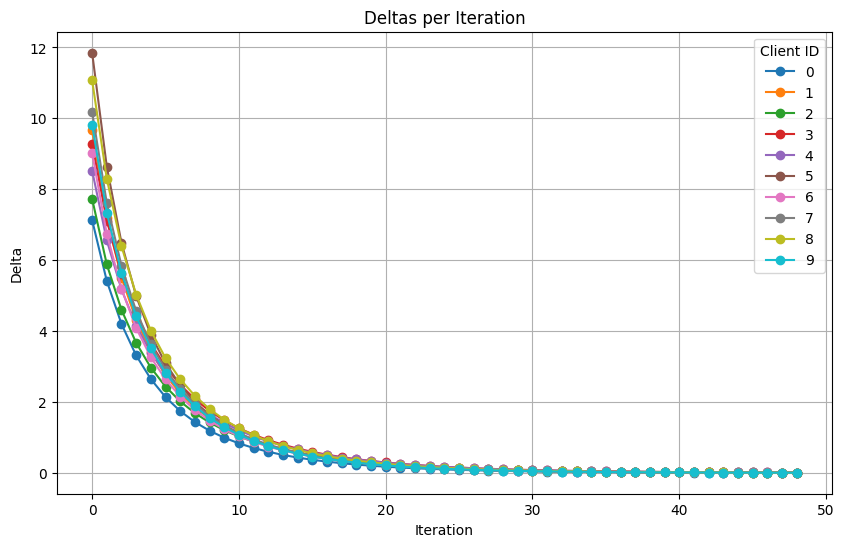

In [19]:
import matplotlib.pyplot as plt
deltas_df.plot(figsize=(10, 6), marker='o')
plt.title("Deltas per Iteration")
plt.xlabel("Iteration")
plt.ylabel("Delta")
plt.grid(True)
plt.legend(title="Client ID")